In [5]:
pip install intake intake-esm gcsfs zarr xarray netCDF4

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install --upgrade pyarrow


Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px 
import plotly.graph_objects as go
import plotly.io as pio
import intake 
import xarray as xr
import pyarrow
import sys
import gcsfs
!{sys.executable} -m pip install --upgrade pyarrow pandas polars intake-esm

  Using cached polars-1.40.1-py3-none-any.whl.metadata (10 kB)


In [20]:
conda install -c conda-forge pyarrow pandas polars intake-esm

Channels:
 - conda-forge
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.3.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [21]:
catalog = pd.read_csv("https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv")
catalog

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
...,...,...,...,...,...,...,...,...,...,...,...
523769,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207
523770,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,tauu,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207
523771,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,hur,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207
523772,CMIP,EC-Earth-Consortium,EC-Earth3-Veg,historical,r1i1p1f1,Amon,hus,gr,gs://cmip6/CMIP6/CMIP/EC-Earth-Consortium/EC-E...,NaN,20211207


In [22]:
cat = catalog[
    (catalog["experiment_id"].isin(["ssp126", "ssp245", "ssp585"])) &
    (catalog["table_id"] == "Omon") &
    (catalog["variable_id"] == "tos") &
    (catalog["member_id"] == "r1i1p1f1")
]

cat[["source_id", "experiment_id", "zstore"]].head()

,source_id,experiment_id,zstore
2415,GFDL-CM4,ssp245,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
2416,GFDL-CM4,ssp245,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-CM...
12075,GFDL-ESM4,ssp585,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...
12076,GFDL-ESM4,ssp585,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...
13957,GFDL-ESM4,ssp126,gs://cmip6/CMIP6/ScenarioMIP/NOAA-GFDL/GFDL-ES...


In [27]:
models = (
    cat.groupby("source_id")["experiment_id"]
    .nunique()
    .reset_index()
)

models_with_all_3 = models[models["experiment_id"] == 3]

model = models_with_all_3["source_id"].iloc[0]

print(model)

ACCESS-CM2


In [32]:

def find_lat_lon_names(ds):
    possible_lat = ["lat", "latitude", "nav_lat", "geolat"]
    possible_lon = ["lon", "longitude", "nav_lon", "geolon"]

    lat_name = None
    lon_name = None

    for name in possible_lat:
        if name in ds:
            lat_name = name

    for name in possible_lon:
        if name in ds:
            lon_name = name

    return lat_name, lon_name

fs = gcsfs.GCSFileSystem(token="anon")

all_rows = []

for scenario in ["ssp126", "ssp245", "ssp585"]:

    row = cat[
        (cat["source_id"] == model) &
        (cat["experiment_id"] == scenario)
    ].iloc[0]

    zstore = row["zstore"]

    print("Opening:", model, scenario)

    mapper = fs.get_mapper(zstore)

    ds = xr.open_zarr(
        mapper,
        consolidated=True
    )

    lat_name, lon_name = find_lat_lon_names(ds)

    print("Latitude variable:", lat_name)
    print("Longitude variable:", lon_name)

    lat = ds[lat_name]
    lon = ds[lon_name]

    region_mask = (
        (lat >= 0) &
        (lat <= 40) &
        (lon >= 260) &
        (lon <= 350)
    )

    sst_c = ds["tos"].where(region_mask) - 273.15

    annual = sst_c.groupby("time.year").mean()

    spatial_dims = [dim for dim in annual.dims if dim != "year"]

    regional_mean = annual.mean(dim=spatial_dims, skipna=True)

    temp_df = regional_mean.to_dataframe(
        name="mean_sst_c"
    ).reset_index()

    temp_df["scenario"] = scenario
    temp_df["model"] = model

    all_rows.append(temp_df)

cmip6_sst = pd.concat(all_rows, ignore_index=True)

cmip6_sst.head()
cmip6_sst.head()

Opening: ACCESS-CM2 ssp126
Latitude variable: latitude
Longitude variable: longitude
Opening: ACCESS-CM2 ssp245
Latitude variable: latitude
Longitude variable: longitude
Opening: ACCESS-CM2 ssp585


/var/folders/rd/rv0859t50gqf0xnbs_4ffty80000gn/T/ipykernel_78613/616050766.py:35: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(
/var/folders/rd/rv0859t50gqf0xnbs_4ffty80000gn/T/ipykernel_78613/616050766.py:35: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_zarr(
/var/folders/rd/rv0859t50gqf0xnbs_4ffty80000gn/T/ipykernel_78613/616050766.py:35: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a

Latitude variable: latitude
Longitude variable: longitude


,year,mean_sst_c,scenario,model
0,2015,-246.925003,ssp126,ACCESS-CM2
1,2016,-246.939545,ssp126,ACCESS-CM2
2,2017,-246.898239,ssp126,ACCESS-CM2
3,2018,-247.093704,ssp126,ACCESS-CM2
4,2019,-246.708099,ssp126,ACCESS-CM2


In [33]:
cmip6_sst.to_csv("cmip6_sst_scenarios.csv", index=False)

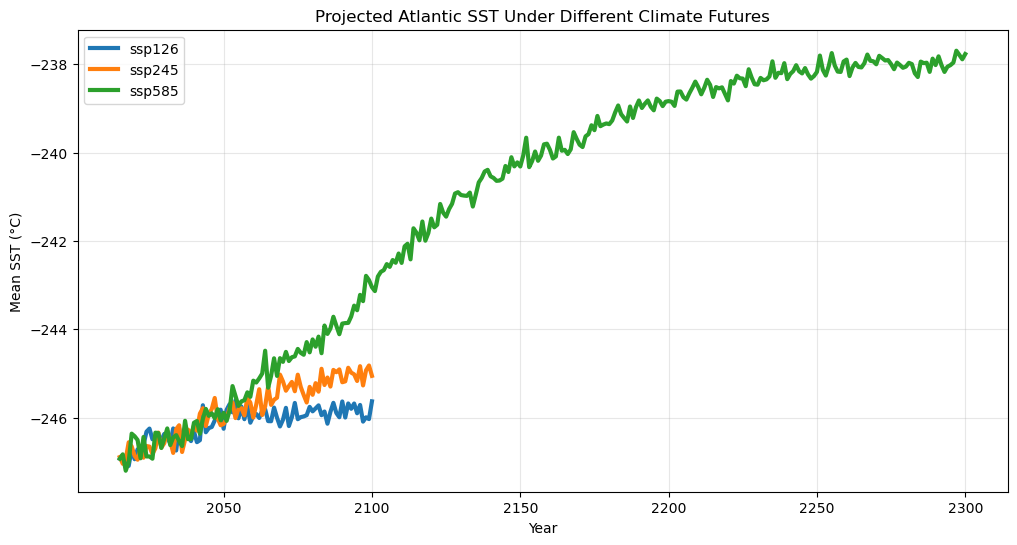

In [34]:
cmip6 = pd.read_csv("cmip6_sst_scenarios.csv")

plt.figure(figsize=(12,6))

for scenario in cmip6["scenario"].unique():

    subset = cmip6[
        cmip6["scenario"] == scenario
    ]

    plt.plot(
        subset["year"],
        subset["mean_sst_c"],
        linewidth=3,
        label=scenario
    )

plt.title("Projected Atlantic SST Under Different Climate Futures")
plt.xlabel("Year")
plt.ylabel("Mean SST (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "cmip6_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

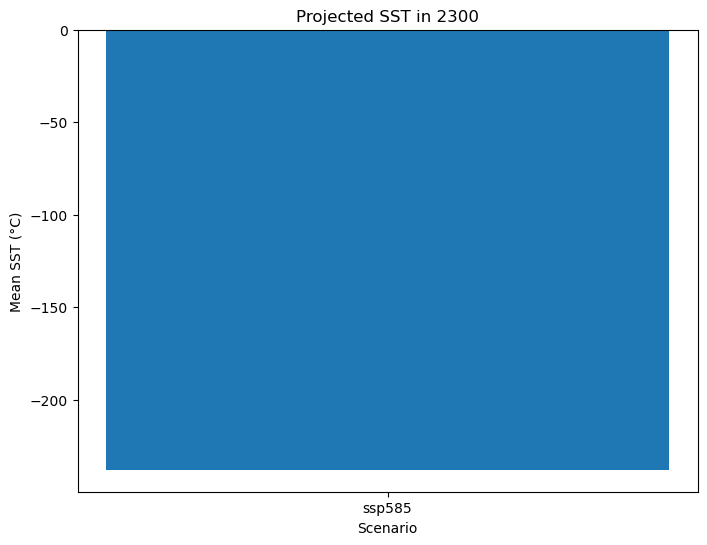

In [35]:
latest_year = cmip6["year"].max()

final_data = cmip6[
    cmip6["year"] == latest_year
]

plt.figure(figsize=(8,6))

plt.bar(
    final_data["scenario"],
    final_data["mean_sst_c"]
)

plt.title(f"Projected SST in {latest_year}")
plt.xlabel("Scenario")
plt.ylabel("Mean SST (°C)")

plt.savefig(
    "scenario_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


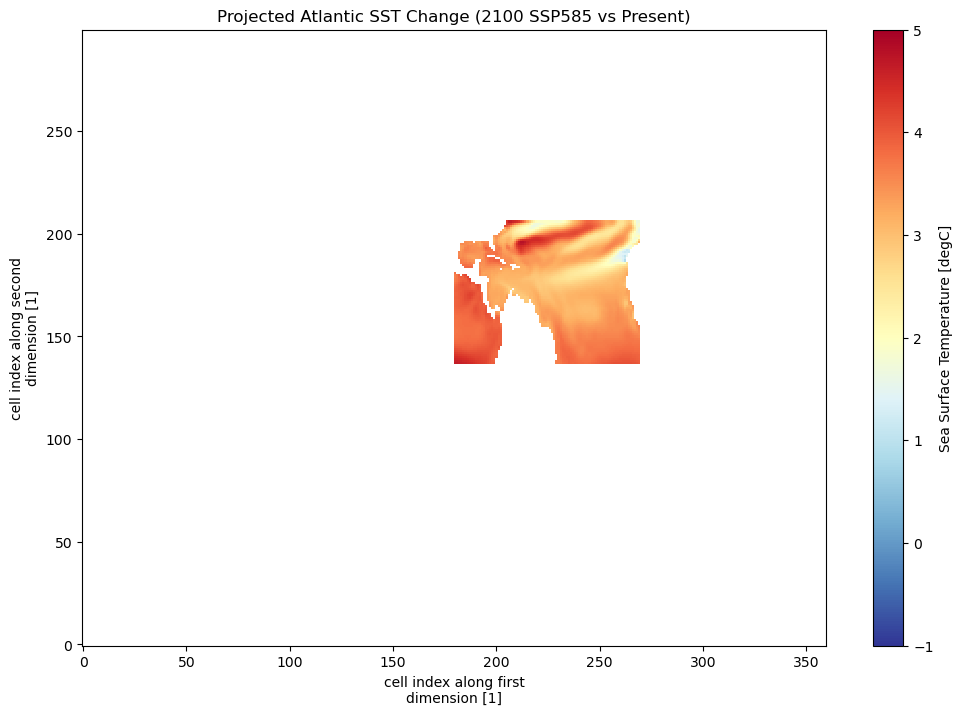

In [37]:
baseline = sst_c.sel(
    time=slice("2015", "2025")
).mean("time")

future = sst_c.sel(
    time=slice("2090", "2100")
).mean("time")

anomaly = future - baseline

plt.figure(figsize=(12,8))

anomaly.plot(
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=5
)

plt.title("Projected Atlantic SST Change (2100 SSP585 vs Present)")

plt.savefig(
    "sst_anomaly_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
baseline = cmip6[
    cmip6["year"] < 2030
]["mean_sst_c"].mean()

cmip6["anomaly"] = (
    cmip6["mean_sst_c"] - baseline
)

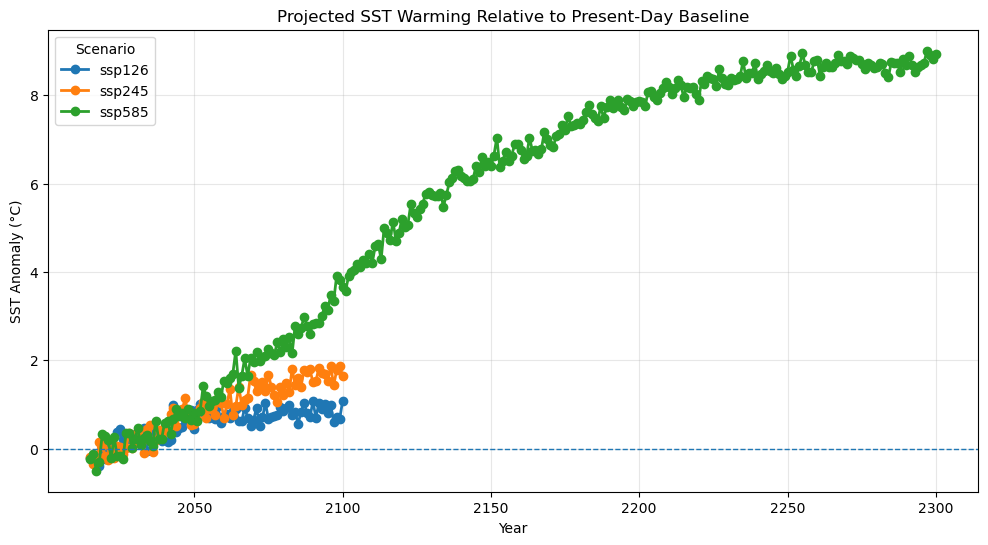

In [39]:
baseline = cmip6[cmip6["year"] <= 2030]["mean_sst_c"].mean()

cmip6["sst_anomaly_c"] = cmip6["mean_sst_c"] - baseline

plt.figure(figsize=(12, 6))

for scenario in cmip6["scenario"].unique():
    subset = cmip6[cmip6["scenario"] == scenario]

    plt.plot(
        subset["year"],
        subset["sst_anomaly_c"],
        marker="o",
        linewidth=2,
        label=scenario
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Projected SST Warming Relative to Present-Day Baseline")
plt.xlabel("Year")
plt.ylabel("SST Anomaly (°C)")
plt.legend(title="Scenario")
plt.grid(alpha=0.3)

plt.savefig("cmip6_sst_anomaly_chart.png", dpi=300, bbox_inches="tight")
plt.show()

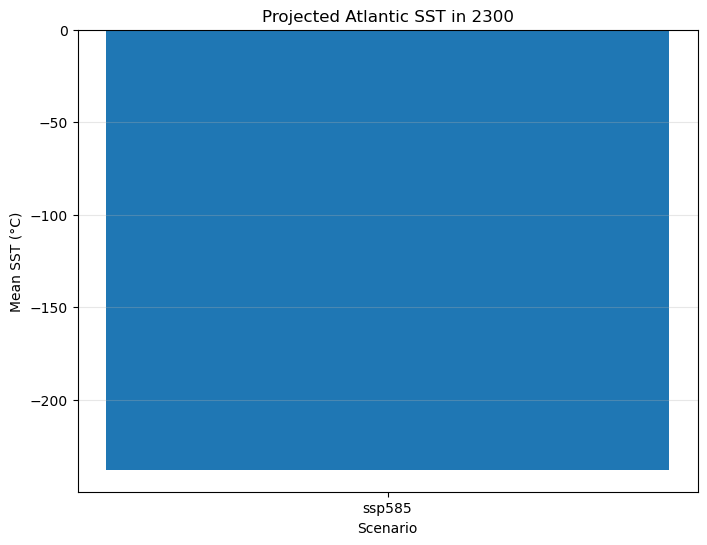

In [40]:
latest_year = cmip6["year"].max()

final_data = cmip6[cmip6["year"] == latest_year]

plt.figure(figsize=(8, 6))

plt.bar(
    final_data["scenario"],
    final_data["mean_sst_c"]
)

plt.title(f"Projected Atlantic SST in {latest_year}")
plt.xlabel("Scenario")
plt.ylabel("Mean SST (°C)")
plt.grid(axis="y", alpha=0.3)

plt.savefig("cmip6_final_year_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

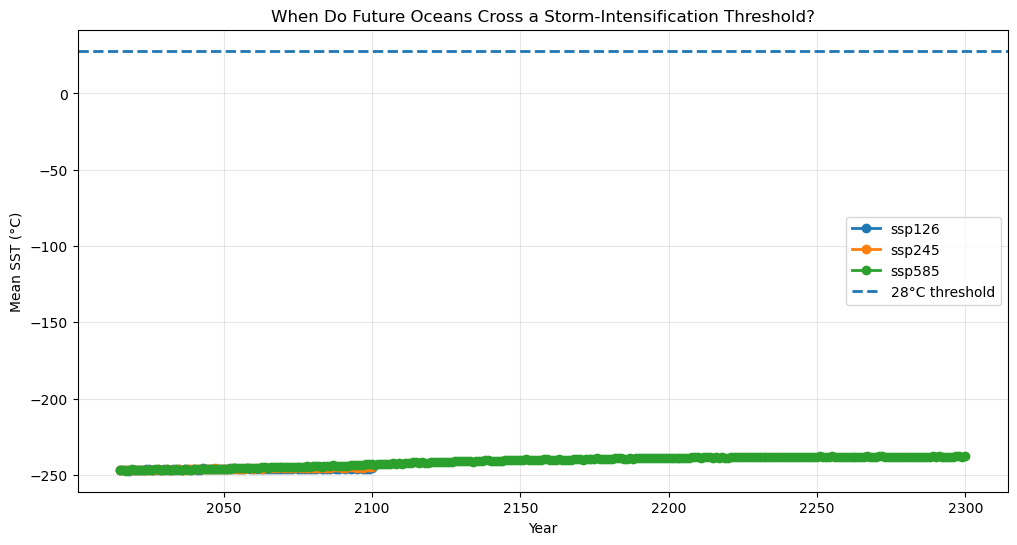

In [41]:
threshold = 28

plt.figure(figsize=(12, 6))

for scenario in cmip6["scenario"].unique():
    subset = cmip6[cmip6["scenario"] == scenario]

    plt.plot(
        subset["year"],
        subset["mean_sst_c"],
        marker="o",
        linewidth=2,
        label=scenario
    )

plt.axhline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"{threshold}°C threshold"
)

plt.title("When Do Future Oceans Cross a Storm-Intensification Threshold?")
plt.xlabel("Year")
plt.ylabel("Mean SST (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("cmip6_threshold_crossing.png", dpi=300, bbox_inches="tight")
plt.show()

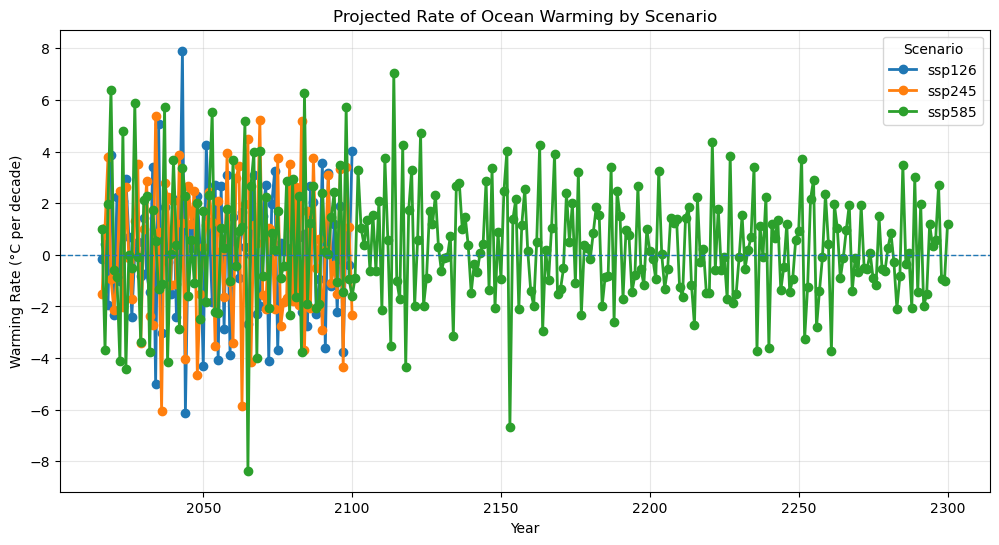

In [42]:
cmip6["warming_rate_per_year"] = (
    cmip6.groupby("scenario")["mean_sst_c"].diff()
    /
    cmip6.groupby("scenario")["year"].diff()
)

cmip6["warming_rate_per_decade"] = cmip6["warming_rate_per_year"] * 10

rate_data = cmip6.dropna(subset=["warming_rate_per_decade"])

plt.figure(figsize=(12, 6))

for scenario in rate_data["scenario"].unique():
    subset = rate_data[rate_data["scenario"] == scenario]

    plt.plot(
        subset["year"],
        subset["warming_rate_per_decade"],
        marker="o",
        linewidth=2,
        label=scenario
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Projected Rate of Ocean Warming by Scenario")
plt.xlabel("Year")
plt.ylabel("Warming Rate (°C per decade)")
plt.legend(title="Scenario")
plt.grid(alpha=0.3)

plt.savefig("cmip6_warming_rate.png", dpi=300, bbox_inches="tight")
plt.show()